# Exercise 5

## Train 2 decision trees using sklearn and plot the result

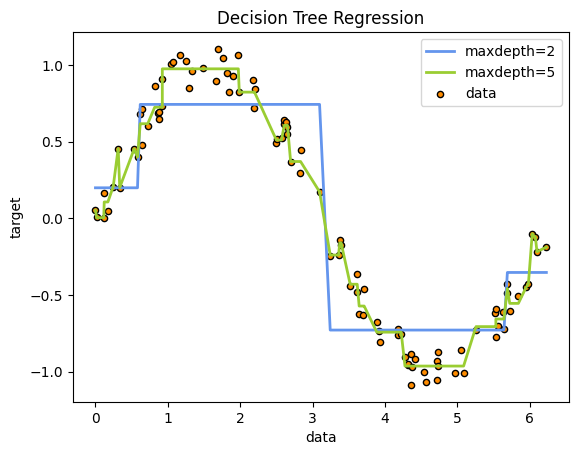

In [ ]:
# Import the necessary modules and libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
y_1 = regr_1.predict(X)
y_2 = regr_2.predict(X)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X, y_1, color="cornflowerblue",
         label="maxdepth=2", linewidth=2)
plt.plot(X, y_2, color="yellowgreen", label="maxdepth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## Create my own decision tree

In [2]:
def My_TreeRegressor(y, il, ir, max_depth, level=0):
    global yreg
    
    if level == 0:
        yreg = np.zeros(len(y))
    
    # First base case, if the interval only contains one point
    if il == ir:
        yreg[il] = y[il]
        return
    
    # Second base case, if we reach the end of the depth, give all the points the average value
    if level == max_depth:
        leaf_value = np.mean(y[il:ir+1])
        yreg[il:ir+1] = leaf_value
        return
    
    # Search for the best split by trying every combination
    best_cost = np.inf
    best_split = None
    
    for s in range(il, ir):
        left_mean  = np.mean(y[il:s+1])
        right_mean = np.mean(y[s+1:ir+1])
        
        cost_left  = np.sum((y[il:s+1]     - left_mean)**2)
        cost_right = np.sum((y[s+1:ir+1]   - right_mean)**2)
        cost = cost_left + cost_right
        
        if cost < best_cost:
            best_cost = cost
            best_split = s
    
    # Recursive calls to build the tree
    My_TreeRegressor(y, il, best_split, max_depth, level+1)
    My_TreeRegressor(y, best_split+1, ir, max_depth, level+1)


## Run my tree regressor and plot the result together with the result from sklearn

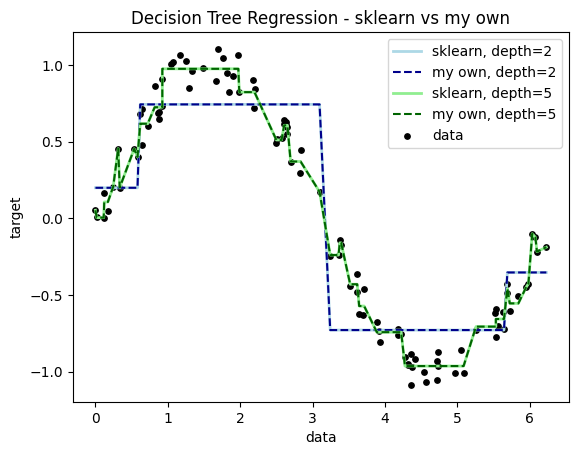

In [3]:
My_TreeRegressor(y, 0, len(y)-1, max_depth=2)
y_custom_2 = yreg.copy()

My_TreeRegressor(y, 0, len(y)-1, max_depth=5)
y_custom_5 = yreg.copy()


plt.figure()
plt.scatter(X, y, s=15, c="black", label="data")

plt.plot(X, y_1, color="lightblue", label="sklearn, depth=2", linewidth=2)
plt.plot(X, y_custom_2, color="darkblue", linestyle="--", label="my own, depth=2")

plt.plot(X, y_2, color="lightgreen", label="sklearn, depth=5", linewidth=2)
plt.plot(X, y_custom_5, color="darkgreen", linestyle="--", label="my own, depth=5")

plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression - sklearn vs my own")
plt.legend()
plt.show()


## Do the plots agree?

For both depths (2 and 5), the piecewise‑constant curves produced by my implementation lie (what I can see) exactly on top of the corresponding scikit‑learn predictions. This confirms that the recursive splitting procedure, the cost calculation, and the leaf assignments in my implementation match the behavior of a standard decision‑tree regressor.